# ISeeSnow three-case manuscript figure

This notebook creates the cross-case AVAC4QGIS intercomparison figure from archived exact-grid field summaries. It does not rerun AVAC or modify any participating-model field.


## Reproducible environment

The first code cell installs the repository's validation package and Python dependencies into the active kernel. A clean checkout also needs GNU Make and gfortran to compile the selected solver on first use.


In [1]:
from pathlib import Path
SEARCH_ROOT = Path.cwd().resolve()
REPOSITORY = next(candidate for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents) if (candidate / 'validation' / 'pyproject.toml').is_file())
%pip install -q -e {REPOSITORY / 'validation'}


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from avac4qgis_validation import validation_case
case = validation_case('ISeeSnow', 'Paper_figures')
CORES = max(1, os.cpu_count() or 1)
case.path


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/Paper_figures')

In [8]:
case.run(case.path.parent / 'compare_iseesnow.py', '--case', 'all', cwd=case.path.parent)
case.run('make_iseesnow_case_figure.py')
case.run('make_iseesnow_figures.py')


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/compare_iseesnow.py --case all
{
  "comparisons": 44,
  "exclusions": 11
}
Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/Paper_figures/make_iseesnow_case_figure.py
{
  "output": "/Users/cmgotelli/Desktop/AVAC-QGIS/docs/article/figures",
  "cases": 3
}
Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/Paper_figures/make_iseesnow_figures.py
{
  "avac_field_source": "/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/field_summary.csv",
  "peer_scalar_source": "/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/Paper_figures/iseesnow_table_c1_core.csv",
  "peer_group": "ISeeSnow Table C1 core group",
  "runout_definition": "furthest thalweg coordinate with PFT > 0.5 m",
  "cases": {
    "IdealizedTopo": {
      "runout_length_m": {
        "peer_count": 11,
        "peer_q1"

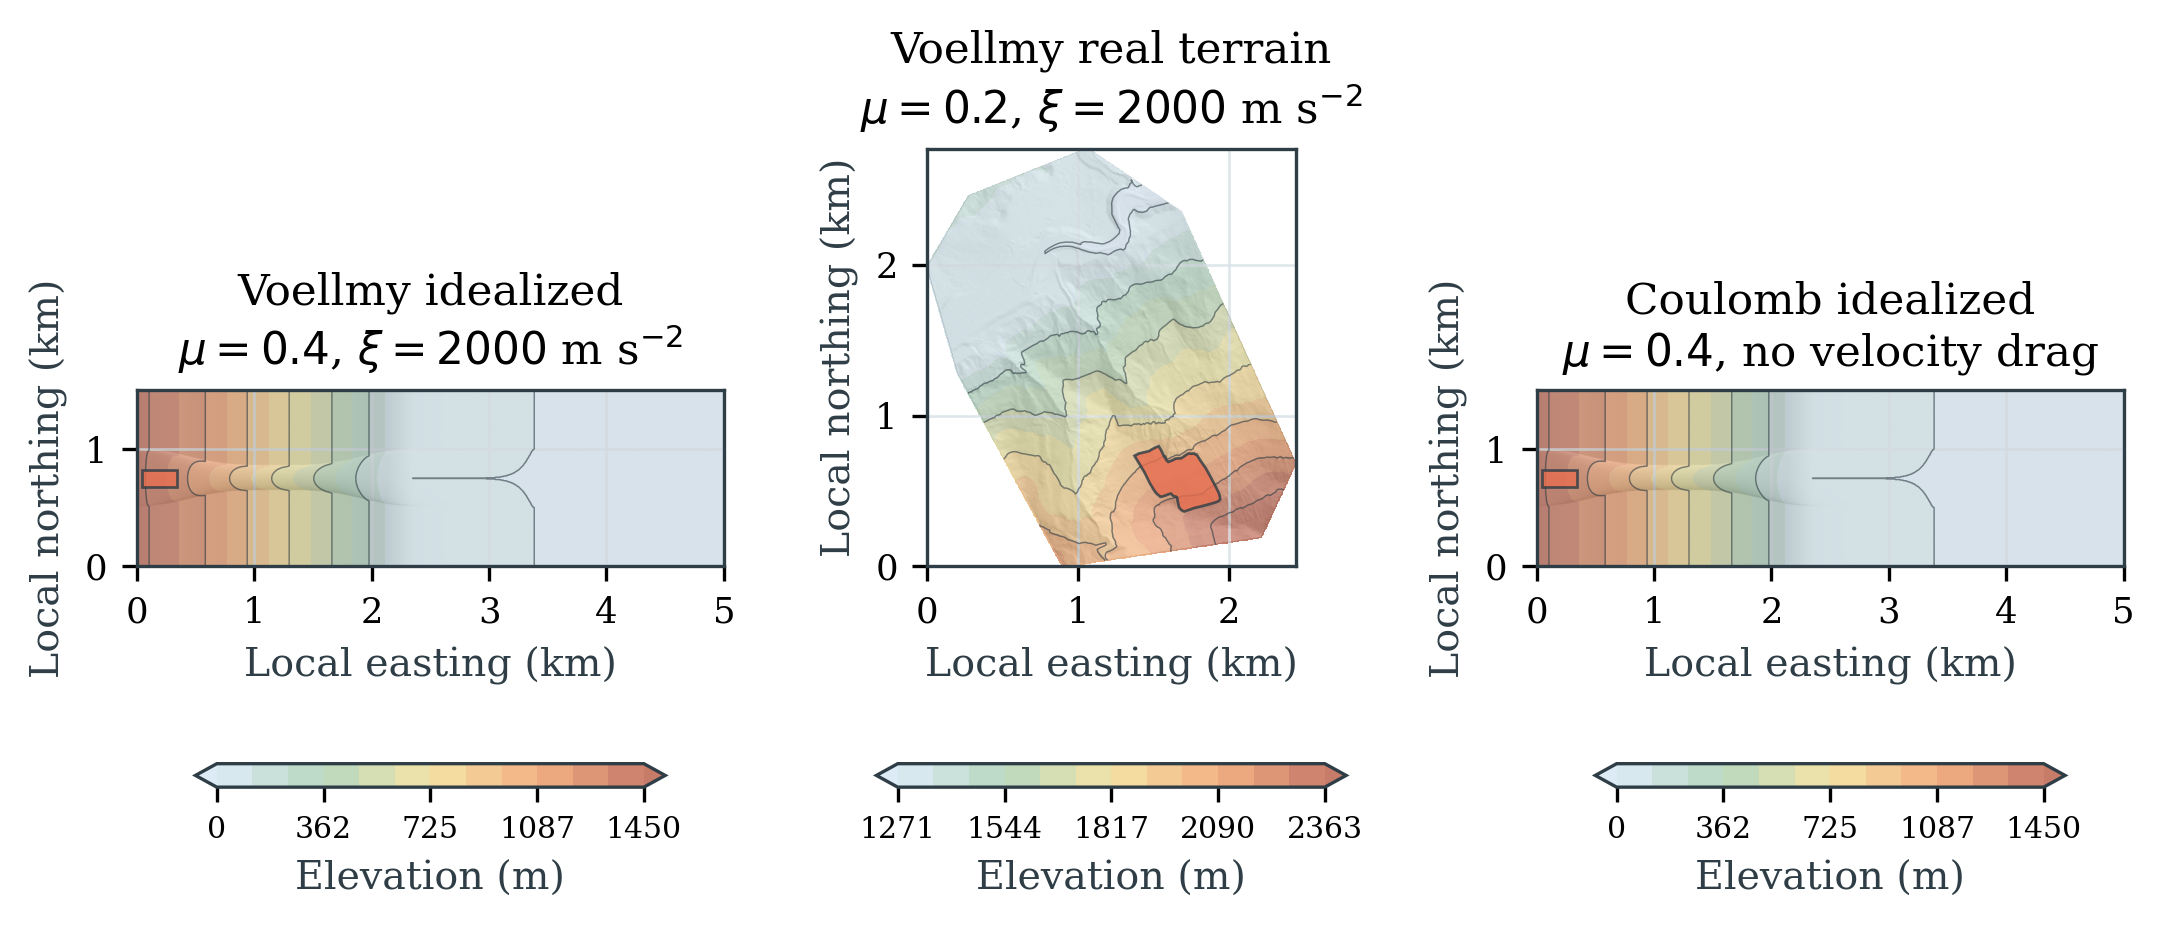

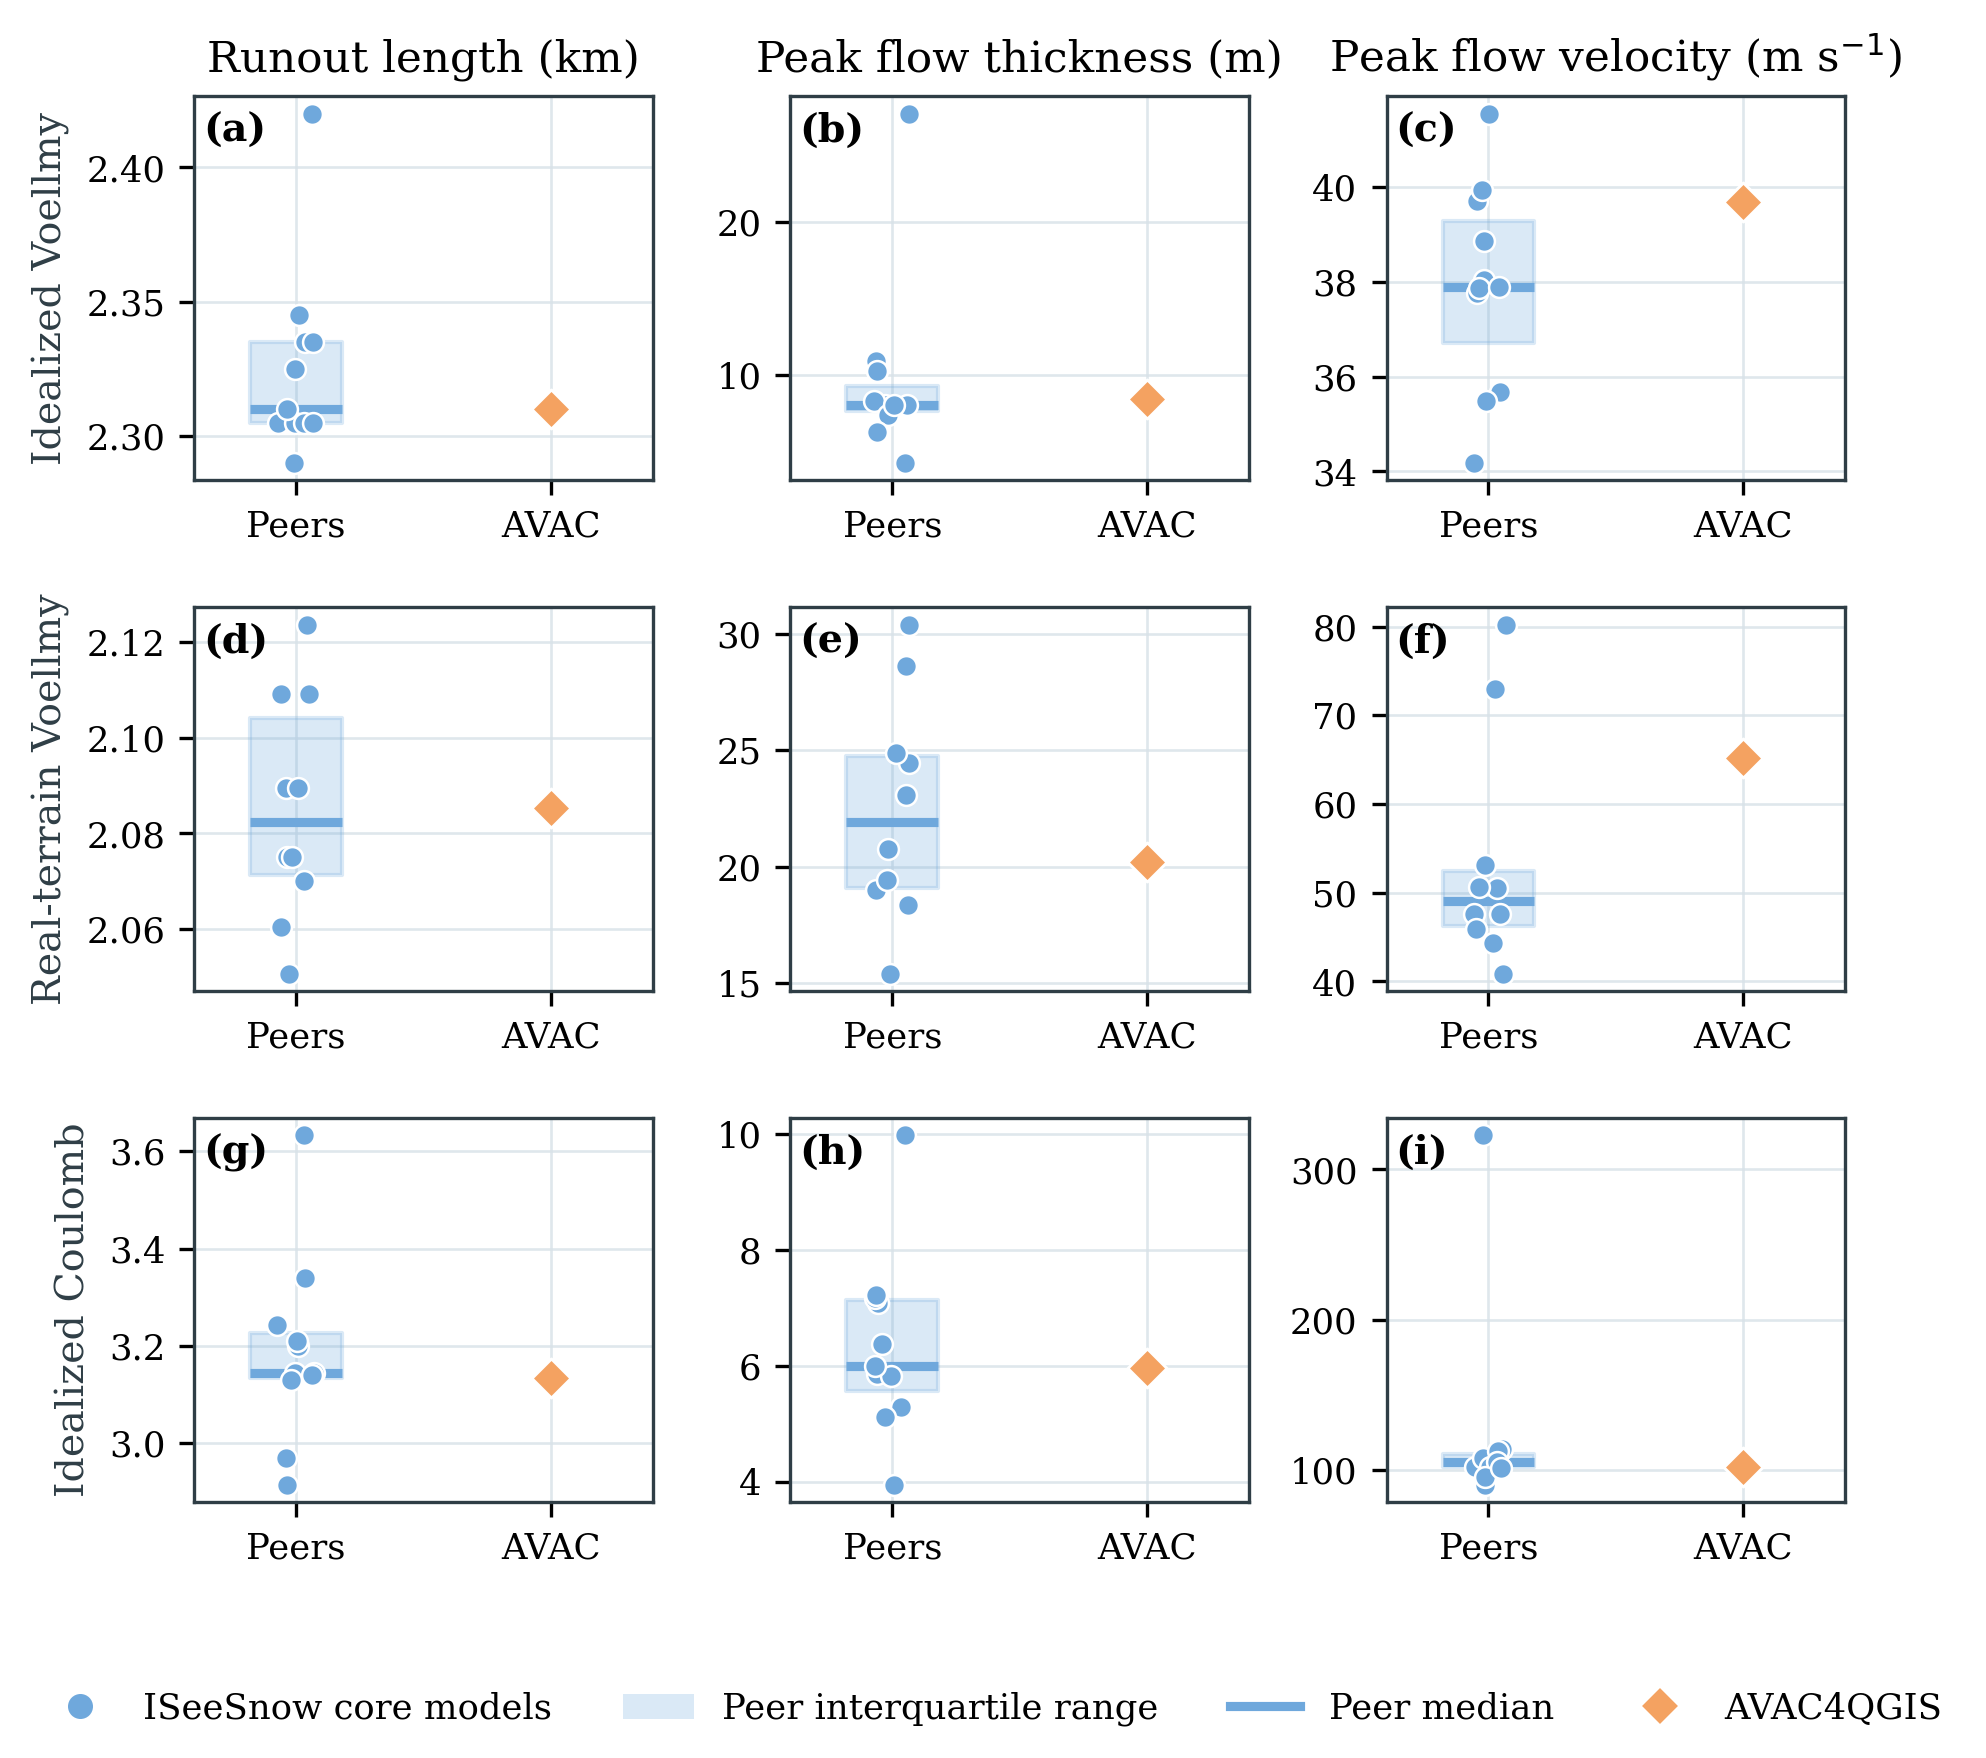

In [9]:
case.show('../../../docs/article/figures/iseesnow_case_setup.png', '../../../docs/article/figures/iseesnow_intercomparison.png')
